# CNN Architecture Visualization & Image Recognition

**Lab Objectives:**
- Understand how a Convolutional Neural Network (CNN) processes images
- Build a simple CNN from scratch using TensorFlow/Keras (no OOP)
- Train the model on CIFAR-10 (10-class image dataset)
- **Visualize feature maps** — see what the network "sees" at each layer
- **Visualize learned filters** — see what patterns the network learned

---

## What is a CNN?

A **Convolutional Neural Network (CNN)** is a type of neural network designed for image data.  
Unlike a regular Dense network that flattens the image and loses spatial structure,  
a CNN uses **sliding filters** to detect local patterns (edges, textures, shapes).

```
Input Image → [Conv → Pool] × N → Flatten → Dense → Output
```

**Key layers:**
| Layer | What it does |
|---|---|
| `Conv2D` | Slides a small filter over the image to detect local patterns |
| `MaxPooling2D` | Shrinks the feature map by keeping only the max value in each region |
| `Flatten` | Converts 2D feature maps into a 1D vector |
| `Dense` | Fully connected layer that learns high-level combinations |
| `Dropout` | Randomly turns off neurons during training to prevent overfitting |

---

## Dataset: CIFAR-10

- **60,000** colour images, each **32×32 pixels**, **3 channels (RGB)**
- **10 classes**: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck
- Split: 50,000 training + 10,000 test

---
## Install & Import Libraries

In [ ]:
# TensorFlow is pre-installed on Colab, but we import everything we need here.
# numpy  → numerical operations and array handling
# matplotlib → plotting images, graphs, feature maps
# tensorflow / keras → building and training the CNN

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Reproducibility: fix random seeds so results are consistent across runs
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## Load & Explore the Dataset

`cifar10.load_data()` downloads the dataset automatically (first run only ~163 MB).  
It returns two tuples:
- `(x_train, y_train)` — 50,000 training images + labels
- `(x_test, y_test)`  — 10,000 test images + labels

Each image shape: **(height=32, width=32, channels=3)**  
Each label: a single integer in `[0, 9]`

In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("=== Dataset shapes ===")
print(f"x_train : {x_train.shape}   (N, H, W, C)")
print(f"y_train : {y_train.shape}")
print(f"x_test  : {x_test.shape}")
print(f"y_test  : {y_test.shape}")
print(f"\nPixel value range  : {x_train.min()} – {x_train.max()}")
print(f"Number of classes  : {len(CLASS_NAMES)}")
print(f"Classes            : {CLASS_NAMES}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
=== Dataset shapes ===
x_train : (50000, 32, 32, 3)   (N, H, W, C)
y_train : (50000, 1)
x_test  : (10000, 32, 32, 3)
y_test  : (10000, 1)

Pixel value range  : 0 – 255
Number of classes  : 10
Classes            : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


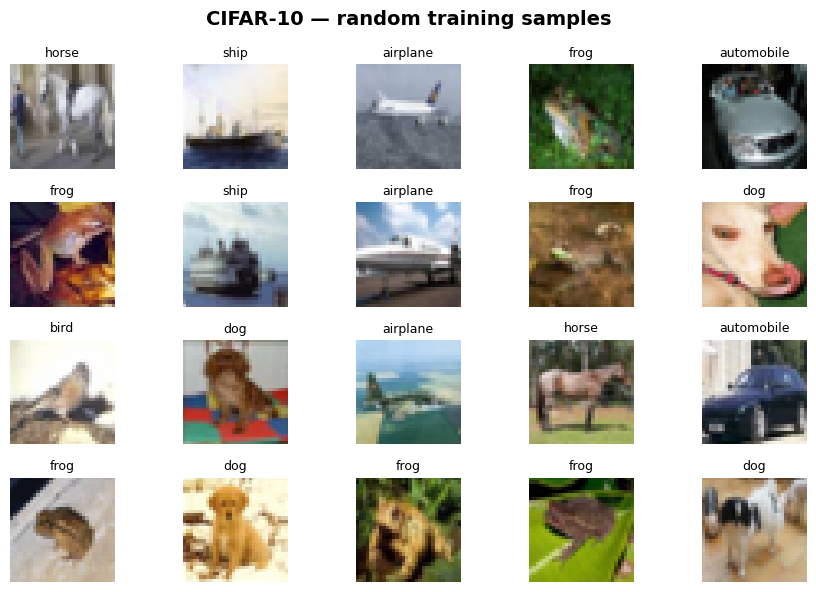

In [ ]:
# ── Visualise 20 random training images ──────────────────────────────
# This helps us understand what the CNN needs to learn to classify.

fig, axes = plt.subplots(4, 5, figsize=(9, 6))
fig.suptitle("CIFAR-10 — random training samples", fontsize=14, fontweight='bold')

indices = np.random.choice(len(x_train), 20, replace=False)

for ax, idx in zip(axes.flat, indices):
    ax.imshow(x_train[idx])
    ax.set_title(CLASS_NAMES[y_train[idx][0]], fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

# Note: images look small and "blocky" because they are only 32x32 pixels.
# The CNN still learns to classify them with ~70-75% accuracy.

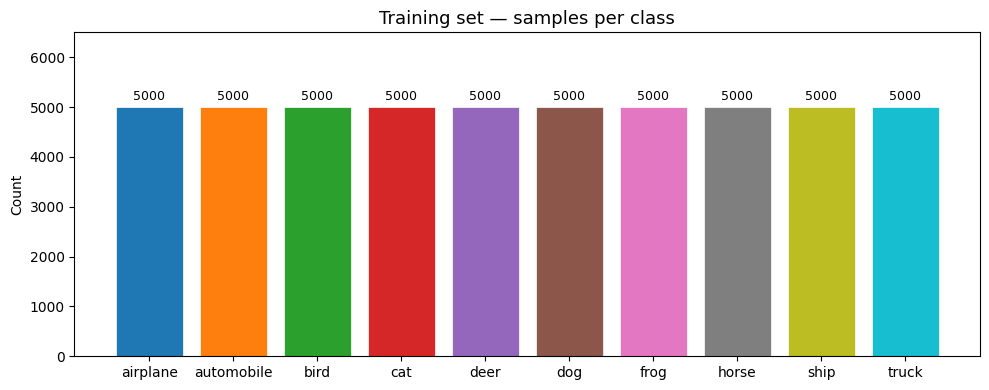

Each class has exactly 5,000 training images → perfectly balanced dataset.


In [ ]:
# ── Class distribution ─────────────────────────────────────────────
# It is important to check that classes are balanced.
# An imbalanced dataset can cause the model to bias toward frequent classes.

unique, counts = np.unique(y_train, return_counts=True)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(CLASS_NAMES, counts, color=plt.cm.tab10.colors, edgecolor='white', linewidth=0.5)
ax.set_title("Training set — samples per class", fontsize=13)
ax.set_ylabel("Count")
ax.set_ylim(0, 6500)

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
            str(count), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("Each class has exactly 5,000 training images → perfectly balanced dataset.")

---
## Preprocessing

Two steps before we can train:

### 2a. Normalise pixel values
Raw pixels are integers in **[0, 255]**.  
We divide by 255 to get floats in **[0.0, 1.0]**.  
This keeps weight updates small and stable during training (gradient descent converges faster).

### 2b. One-hot encode labels
The label `3` (cat) becomes `[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]`.  
This is needed because our output layer has **10 neurons** (one per class),  
and cross-entropy loss compares the predicted probability vector with this one-hot vector.

In [ ]:
# Normalise ─────────────────────────────────────────────────────
# Cast to float32 first (default is uint8), then divide.
# Only normalise if not already done
if x_train.dtype != np.float32 or x_train.max() > 1.0:
    x_train = x_train.astype("float32") / 255.0
    x_test  = x_test.astype("float32")  / 255.0
else:
    print("Already normalised — skipping.")

print("After normalisation:")
print(f"  x_train dtype : {x_train.dtype}")
print(f"  x_train range : {x_train.min():.2f} – {x_train.max():.2f}")

# ── 2b. One-hot encode ───────────────────────────────────────────────
y_train_ohe = to_categorical(y_train, num_classes=10)
y_test_ohe  = to_categorical(y_test,  num_classes=10)

print(f"\nOriginal label for sample 0 : {y_train[0]} ({CLASS_NAMES[y_train[0][0]]})")
print(f"One-hot encoded             : {y_train_ohe[0]}")
print(f"\ny_train_ohe shape: {y_train_ohe.shape}  : 50000 samples × 10 classes")

After normalisation:
  x_train dtype : float32
  x_train range : 0.00 – 1.00

Original label for sample 0 : [6] (frog)
One-hot encoded             : [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]

y_train_ohe shape: (50000, 10)  : 50000 samples × 10 classes


---
## Build the CNN

We use the **Keras Functional API** — no classes, just functions chained together.

### Architecture diagram
```
Input(32×32×3)
   │
   ▼
Conv2D(32 filters, 3×3, ReLU)  →  output: 30×30×32
   │
MaxPooling2D(2×2)               →  output: 15×15×32
   │
Conv2D(64 filters, 3×3, ReLU)  →  output: 13×13×64
   │
MaxPooling2D(2×2)               →  output:  6×6×64
   │
Flatten                         →  output: 2304
   │
Dense(256, ReLU)
   │
Dropout(0.5)
   │
Dense(10, Softmax)              →  output: 10 class probabilities
```

### Why these choices?
| Choice | Reason |
|---|---|
| `padding='valid'` | No zero-padding; each conv reduces spatial size by 2 |
| `32 → 64 filters` | Deeper layers learn more complex features; double filters |
| `MaxPooling(2×2)` | Halves width and height → reduces computation + adds translation invariance |
| `Dropout(0.5)` | 50% of neurons randomly disabled each batch → prevents overfitting |
| `Softmax` | Converts raw scores to probabilities summing to 1.0 |

In [ ]:
# Define the CNN using Functional API ──────────────────────

# Step 1: Define the input tensor and its shape
inputs = layers.Input(shape=(32, 32, 3), name="input")
# shape = (height, width, channels) — 32×32 RGB image

# ── BLOCK 1 ──────────────────────────────────────────────────────────
# Conv2D: 32 filters, each 3×3, slide over the image with stride=1
# ReLU activation: output = max(0, x)  — introduces non-linearity
# Output shape: (30, 30, 32)  because (32-3+1) = 30
x = layers.Conv2D(32, (3, 3), activation="relu", padding="valid", name="conv1")(inputs)

# MaxPool: take the max value in each 2×2 window, stride=2
# Output shape: (15, 15, 32)  — spatial size halved
x = layers.MaxPooling2D((2, 2), name="pool1")(x)

# ── BLOCK 2 ──────────────────────────────────────────────────────────
# 64 filters now — deeper layer, more complex feature detectors
# Output shape: (13, 13, 64)
x = layers.Conv2D(64, (3, 3), activation="relu", padding="valid", name="conv2")(x)

# Output shape: (6, 6, 64)
x = layers.MaxPooling2D((2, 2), name="pool2")(x)

# ── CLASSIFIER HEAD ──────────────────────────────────────────────────
# Flatten: convert 3D tensor (6,6,64) to 1D vector of length 6×6×64 = 2304
x = layers.Flatten(name="flatten")(x)

# Dense: fully connected — every input connected to every output neuron
x = layers.Dense(256, activation="relu", name="dense1")(x)

# Dropout: randomly zero 50% of activations during training (not at inference)
x = layers.Dropout(0.5, name="dropout")(x)

# Output layer: 10 neurons (one per class), Softmax gives probabilities
outputs = layers.Dense(10, activation="softmax", name="output")(x)

# ── Build the Model ───────────────────────────────────────────────────
model = models.Model(inputs=inputs, outputs=outputs, name="simple_cnn")

# Print a clean summary: layer names, output shapes, parameter counts
model.summary()

Model: "simple_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 612,042 (2.33 MB)

 Trainable params: 612,042 (2.33 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Count and explain parameters ──────────────────────────────────────
# Understanding WHERE parameters come from is important for designing efficient networks.

conv1_params = (3 * 3 * 3 * 32) + 32      # (kernel_h × kernel_w × in_ch × out_filters) + biases
conv2_params = (3 * 3 * 32 * 64) + 64
dense1_params = (2304 * 256) + 256
output_params = (256 * 10) + 10

print("=== Parameter breakdown ===")
print(f"conv1   : {conv1_params:>8,}  = (3×3×3×32) + 32 biases")
print(f"conv2   : {conv2_params:>8,}  = (3×3×32×64) + 64 biases")
print(f"dense1  : {dense1_params:>8,}  = (2304×256) + 256 biases  ← most params!")
print(f"output  : {output_params:>8,}  = (256×10) + 10 biases")
print(f"{'─'*40}")
print(f"Total   : {conv1_params+conv2_params+dense1_params+output_params:>8,}")

print("\n Most parameters are in the Dense layer — this is typical for CNNs.")
print("   Modern architectures use Global Average Pooling to reduce this.")

=== Parameter breakdown ===
conv1   :      896  = (3×3×3×32) + 32 biases
conv2   :   18,496  = (3×3×32×64) + 64 biases
dense1  :  590,080  = (2304×256) + 256 biases  ← most params!
output  :    2,570  = (256×10) + 10 biases
────────────────────────────────────────
Total   :  612,042

 Most parameters are in the Dense layer — this is typical for CNNs.
   Modern architectures use Global Average Pooling to reduce this.


---
## Compile & Train

### Compile settings
| Setting | Choice | Why |
|---|---|---|
| Optimizer | `adam` | Adaptive learning rate — works well out of the box |
| Loss | `categorical_crossentropy` | Standard for multi-class classification with one-hot labels |
| Metric | `accuracy` | Fraction of correctly classified images |

### Training parameters
- **Epochs** = 15 — full passes over the training data  
- **Batch size** = 64 — images processed together before each weight update  
- **Validation split** = 10% — 5,000 images held out to monitor overfitting during training

In [ ]:
# ── Compile ───────────────────────────────────────────────────────────
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ── Train ─────────────────────────────────────────────────────────────
# history object stores accuracy and loss values for every epoch
# — we will plot these in Section 5
history = model.fit(
    x_train, y_train_ohe,
    epochs=15,
    batch_size=64,
    validation_split=0.1,   # last 10% of training data used for validation
    verbose=1
)

# ── Final test evaluation ─────────────────────────────────────────────
test_loss, test_acc = model.evaluate(x_test, y_test_ohe, verbose=0)
print(f"\n{'='*35}")
print(f"  Test accuracy : {test_acc*100:.2f}%")
print(f"  Test loss     : {test_loss:.4f}")
print(f"{'='*35}")
print("\nExpected range: 68% – 76% for this simple architecture.")
print("(Deeper models like ResNet reach ~93%+)")

Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.4284 - loss: 1.5722 - val_accuracy: 0.5384 - val_loss: 1.2738
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5645 - loss: 1.2279 - val_accuracy: 0.6316 - val_loss: 1.0413
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6143 - loss: 1.0905 - val_accuracy: 0.6602 - val_loss: 0.9740
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6454 - loss: 1.0073 - val_accuracy: 0.6760 - val_loss: 0.9286
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6730 - loss: 0.9321 - val_accuracy: 0.6936 - val_loss: 0.8808
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6926 - loss: 0.8729 - val_accuracy: 0.7064 - val_loss: 0.8565
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7133 - loss: 0.8136 - val_accuracy: 0.6992 - val_loss: 0.8735
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7294 - loss: 0.7682 - val_accuracy: 0

---
## Training Curves

Training curves show how **accuracy** and **loss** change over epochs for both training and validation sets.

**What to look for:**
- **Good**: Both curves improve together and stay close
- **Overfitting**: Train accuracy keeps rising but val accuracy plateaus or drops
- **Underfitting**: Both curves plateau at a low value — model is too simple

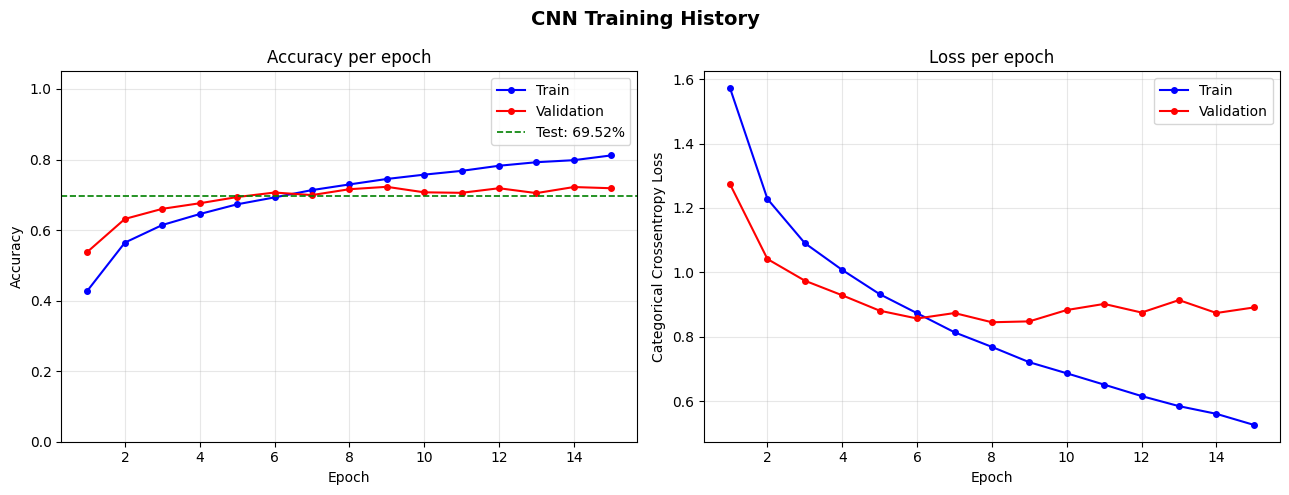

Final train accuracy      : 81.17%
Final validation accuracy : 71.86%
Train-Val gap             : 9.31%
  Gap < 10% → model is generalising reasonably well.


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("CNN Training History", fontsize=14, fontweight="bold")

epochs_range = range(1, len(history.history["accuracy"]) + 1)

def to_displayable(img):
    img = img.astype("float32")
    mn, mx = img.min(), img.max()
    if mx - mn < 1e-6:          # completely flat / all-zero image
        return np.zeros_like(img, dtype=np.uint8)
    img = (img - mn) / (mx - mn) * 255.0
    return img.astype(np.uint8)

# ── Accuracy plot ─────────────────────────────────────────────────────
ax1.plot(epochs_range, history.history["accuracy"],     "b-o", markersize=4, label="Train")
ax1.plot(epochs_range, history.history["val_accuracy"], "r-o", markersize=4, label="Validation")
ax1.set_title("Accuracy per epoch")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.set_ylim(0, 1.05)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.axhline(test_acc, color='green', linestyle='--', linewidth=1.2, label=f"Test: {test_acc:.2%}")
ax1.legend()

# ── Loss plot ─────────────────────────────────────────────────────────
ax2.plot(epochs_range, history.history["loss"],     "b-o", markersize=4, label="Train")
ax2.plot(epochs_range, history.history["val_loss"], "r-o", markersize=4, label="Validation")
ax2.set_title("Loss per epoch")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Categorical Crossentropy Loss")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Diagnose ──────────────────────────────────────────────────────────
final_train = history.history["accuracy"][-1]
final_val   = history.history["val_accuracy"][-1]
gap = final_train - final_val

print(f"Final train accuracy      : {final_train:.2%}")
print(f"Final validation accuracy : {final_val:.2%}")
print(f"Train-Val gap             : {gap:.2%}")
if gap > 0.10:
    print("  Gap > 10% → some overfitting. Consider more Dropout or data augmentation.")
else:
    print("  Gap < 10% → model is generalising reasonably well.")

---
## Feature Map Visualization

**Feature maps** are the outputs (activations) of each layer for a given input image.

They answer the question: **"What does the network see at each stage?"**

### How we do it:
We create a **sub-model** that has the same input as our trained model  
but outputs the intermediate activations instead of just the final prediction:

```python
feature_model = Model(
    inputs  = model.input,
    outputs = [conv1_output, pool1_output, conv2_output, pool2_output]
)
```

### What to expect:
- **conv1** — edge detectors (horizontal, vertical, diagonal lines)
- **pool1** — same features, half the spatial size
- **conv2** — more complex patterns (corners, textures, shapes)
- **pool2** — most spatial detail is gone; only high-level structure remains

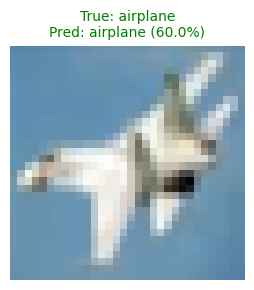

In [ ]:
# ── Pick a sample image ───────────────────────────────────────────────
# We'll use image index 10 from the test set. Change this to explore others.
SAMPLE_IDX = 10

sample_img   = x_test[SAMPLE_IDX:SAMPLE_IDX+1]   # shape (1, 32, 32, 3)
true_label   = CLASS_NAMES[y_test[SAMPLE_IDX][0]]

pred_probs   = model.predict(sample_img, verbose=0)[0]
pred_label   = CLASS_NAMES[np.argmax(pred_probs)]
confidence   = pred_probs.max()

fig, ax = plt.subplots(figsize=(3, 3))
ax.imshow(to_displayable(x_test[SAMPLE_IDX]))
ax.set_title(f"True: {true_label}\nPred: {pred_label} ({confidence:.1%})",
             fontsize=10,
             color='green' if pred_label == true_label else 'red')
ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# ── Build the feature-extraction sub-model ────────────────────────────
# We reuse the ALREADY TRAINED weights — no retraining needed.
# This model outputs activations from 4 layers simultaneously.

layer_names = ["conv1", "pool1", "conv2", "pool2"]

feature_model = models.Model(
    inputs  = model.input,
    outputs = [model.get_layer(name).output for name in layer_names]
)

# Forward pass — get all 4 activation tensors at once
activations = feature_model.predict(sample_img, verbose=0)

# Print shapes so we understand the data
for name, act in zip(layer_names, activations):
    print(f"{name:8s} → activation shape: {act.shape}  "
          f"(H={act.shape[1]}, W={act.shape[2]}, Filters={act.shape[3]})")

conv1    → activation shape: (1, 30, 30, 32)  (H=30, W=30, Filters=32)
pool1    → activation shape: (1, 15, 15, 32)  (H=15, W=15, Filters=32)
conv2    → activation shape: (1, 13, 13, 64)  (H=13, W=13, Filters=64)
pool2    → activation shape: (1, 6, 6, 64)  (H=6, W=6, Filters=64)


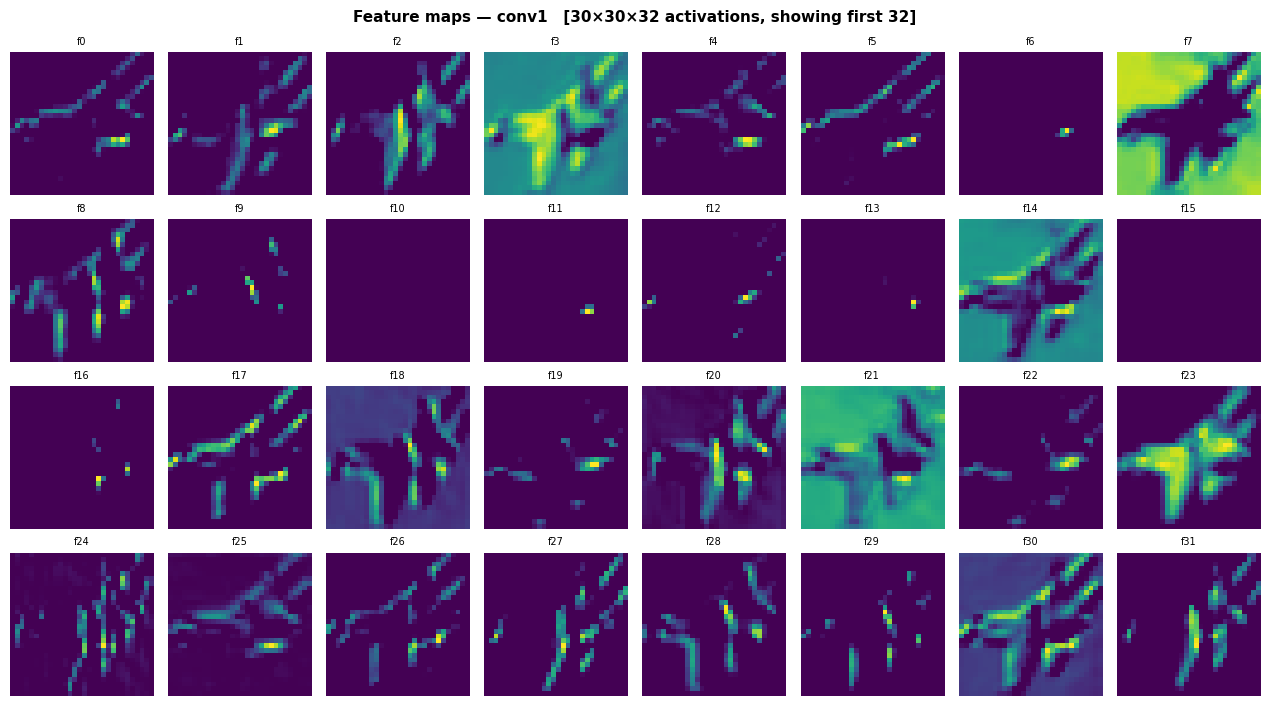

  → Activation range: [0.000, 0.597]
  → Dead filters (all-zero): 2 out of 32



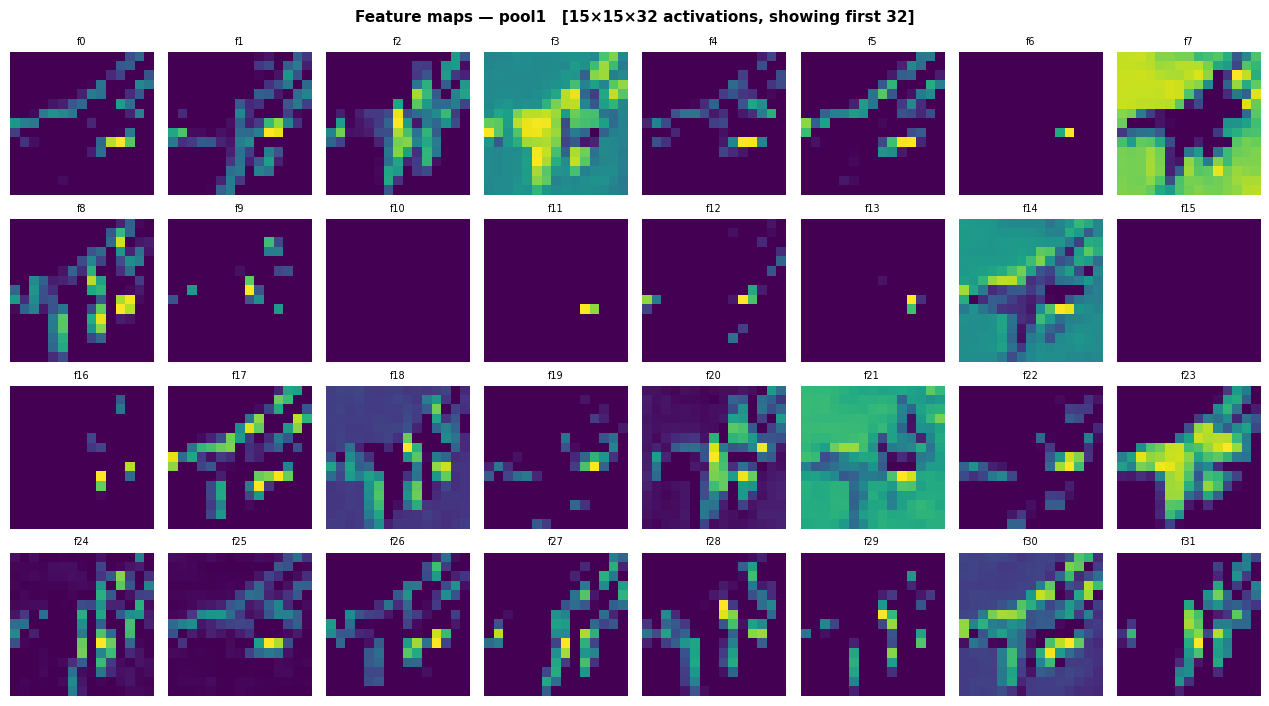

  → Activation range: [0.000, 0.597]
  → Dead filters (all-zero): 2 out of 32



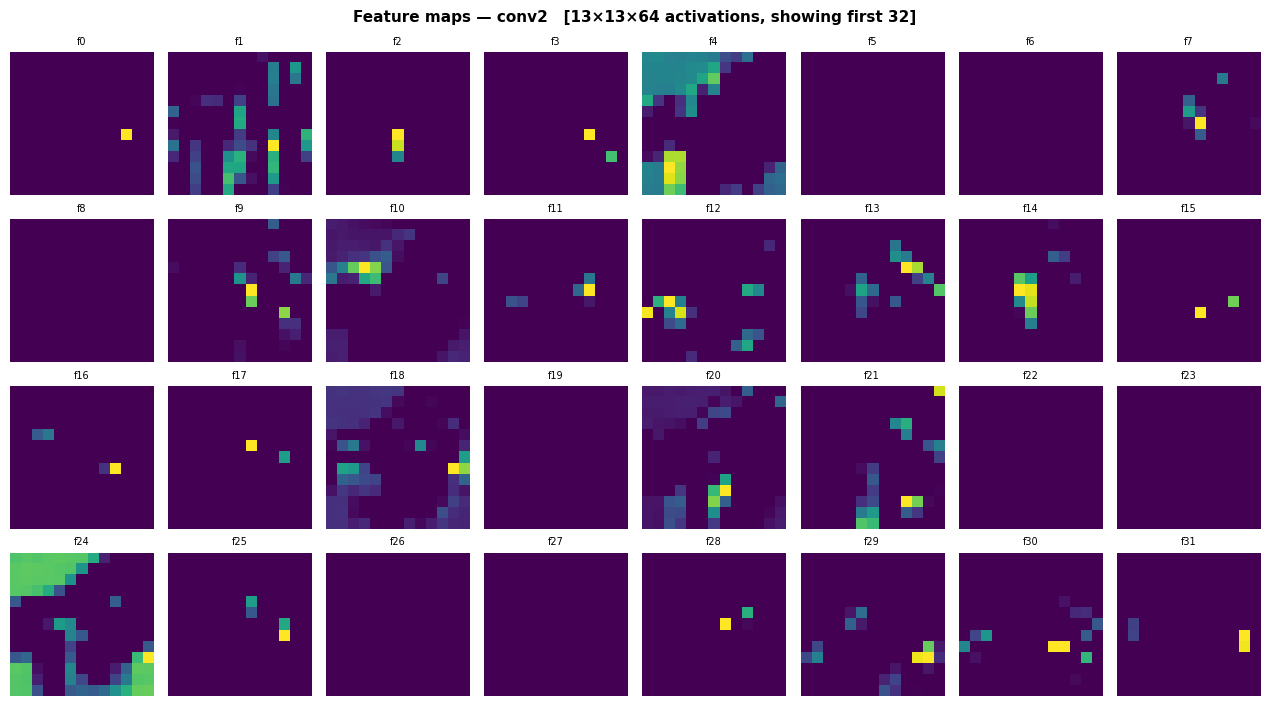

  → Activation range: [0.000, 0.915]
  → Dead filters (all-zero): 14 out of 64



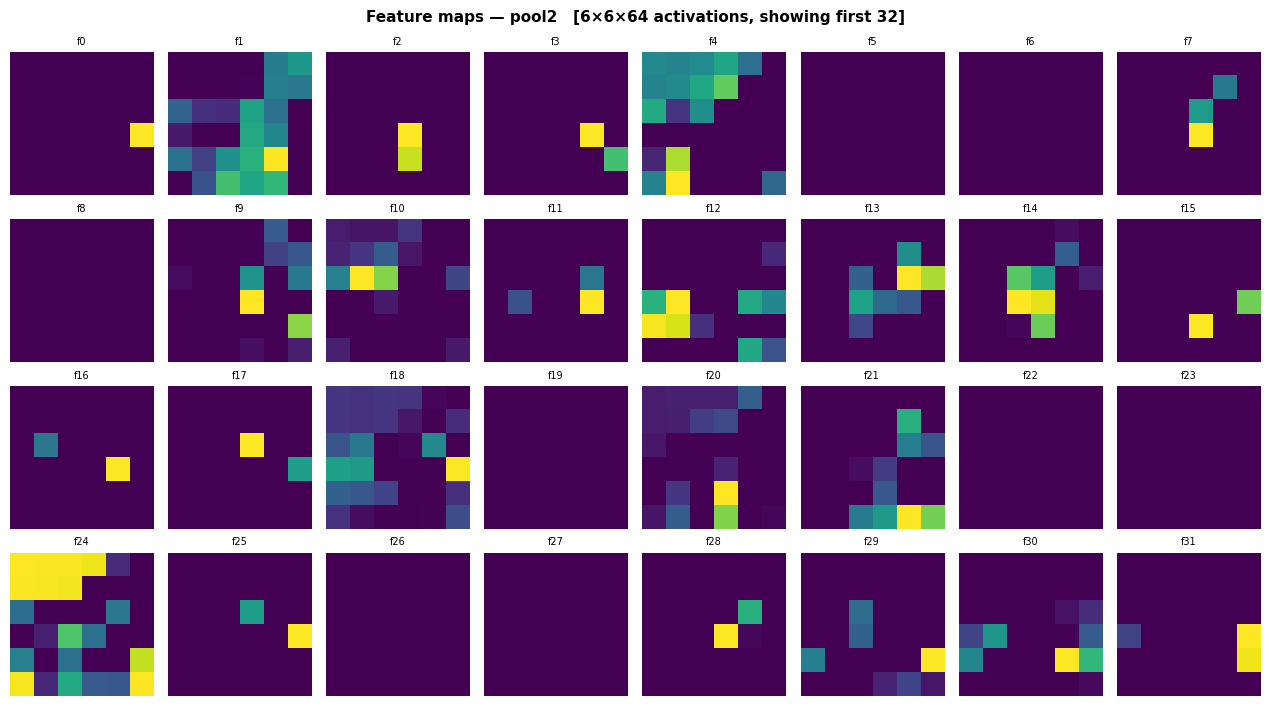

  → Activation range: [0.000, 0.915]
  → Dead filters (all-zero): 14 out of 64



In [ ]:
# ── Helper function: plot feature maps for one layer ─────────────────
def plot_feature_maps(activation, layer_name, max_filters=32):
    """
    activation  : numpy array, shape (1, H, W, num_filters)
    layer_name  : string label shown in the title
    max_filters : how many filters to show (cap to keep plot readable)
    """
    n_filters = min(activation.shape[-1], max_filters)
    cols = 8
    rows = int(np.ceil(n_filters / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.6, rows * 1.8))
    h, w = activation.shape[1], activation.shape[2]
    fig.suptitle(
        f"Feature maps — {layer_name}   "
        f"[{h}×{w}×{activation.shape[3]} activations, showing first {n_filters}]",
        fontsize=11, fontweight='bold'
    )

    for i, ax in enumerate(axes.flat):
        if i < n_filters:
            # activation[0] → remove batch dimension → shape (H, W, filters)
            fmap = activation[0, :, :, i]
            # Use 'viridis' colormap: dark=low activation, bright=high activation
            ax.imshow(fmap, cmap="viridis", interpolation="nearest")
            ax.set_title(f"f{i}", fontsize=7)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    print(f"  → Activation range: [{activation.min():.3f}, {activation.max():.3f}]")
    print(f"  → Dead filters (all-zero): "
          f"{sum(activation[0,:,:,i].max()==0 for i in range(activation.shape[-1]))} "
          f"out of {activation.shape[-1]}\n")


# ── Plot feature maps for all 4 layers ───────────────────────────────
for name, act in zip(layer_names, activations):
    plot_feature_maps(act, name)

Auto-selected filter #25 (range: 0.5975)


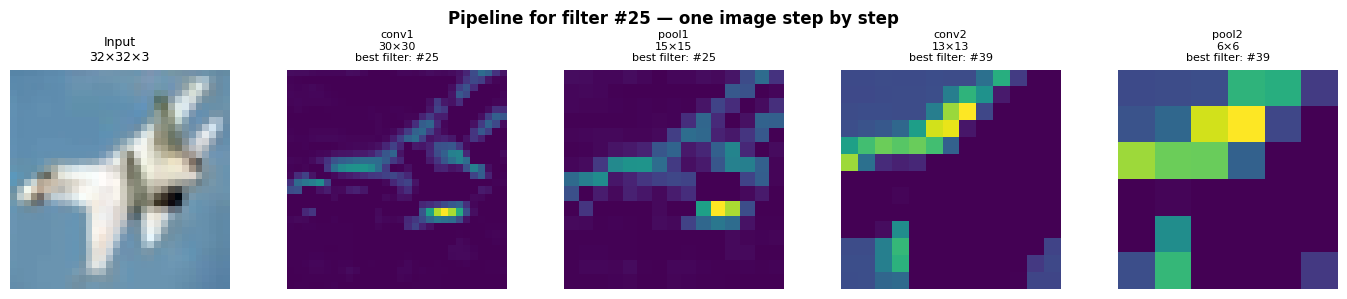

In [ ]:
# ── Auto-select the most active filter for this image ─────────────────
conv1_act = activations[0][0]   # shape (30, 30, 32)

# Pick the filter with the largest activation range in conv1
ranges = [conv1_act[:,:,i].max() - conv1_act[:,:,i].min()
          for i in range(conv1_act.shape[-1])]
FILTER_IDX = int(np.argmax(ranges))
print(f"Auto-selected filter #{FILTER_IDX} (range: {max(ranges):.4f})")

fig, axes = plt.subplots(1, 5, figsize=(14, 3))
fig.suptitle(f"Pipeline for filter #{FILTER_IDX} — one image step by step",
             fontsize=12, fontweight='bold')

axes[0].imshow(to_displayable(x_test[SAMPLE_IDX]))
axes[0].set_title("Input\n32×32×3", fontsize=9)
axes[0].axis("off")

for ax, name, act in zip(axes[1:], layer_names, activations):
    h, w = act.shape[1], act.shape[2]
    # For conv2/pool2, find the most active filter independently
    # because filter indices don't map 1:1 across layers
    best_f = int(np.argmax([act[0,:,:,f].max() - act[0,:,:,f].min()
                             for f in range(act.shape[-1])]))
    fmap = act[0, :, :, best_f]
    ax.imshow(to_displayable(fmap), cmap="viridis")
    ax.set_title(f"{name}\n{h}×{w}\nbest filter: #{best_f}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

---
## Learned Filter Visualization

The actual **weight tensors** of `conv1` are the learned 3×3 filters.  
Each filter is a 3×3×3 array (3×3 spatial, 3 input channels = RGB).  
Plotting them as RGB images reveals the patterns the network learned to detect.

**What common filters look like:**
- Bright on one side, dark on other → **edge detector**
- Colourful patches → **colour blob detector**
- Striped → **texture/frequency detector**

conv1 kernel shape : (3, 3, 3, 32)
conv1 biases shape : (32,)


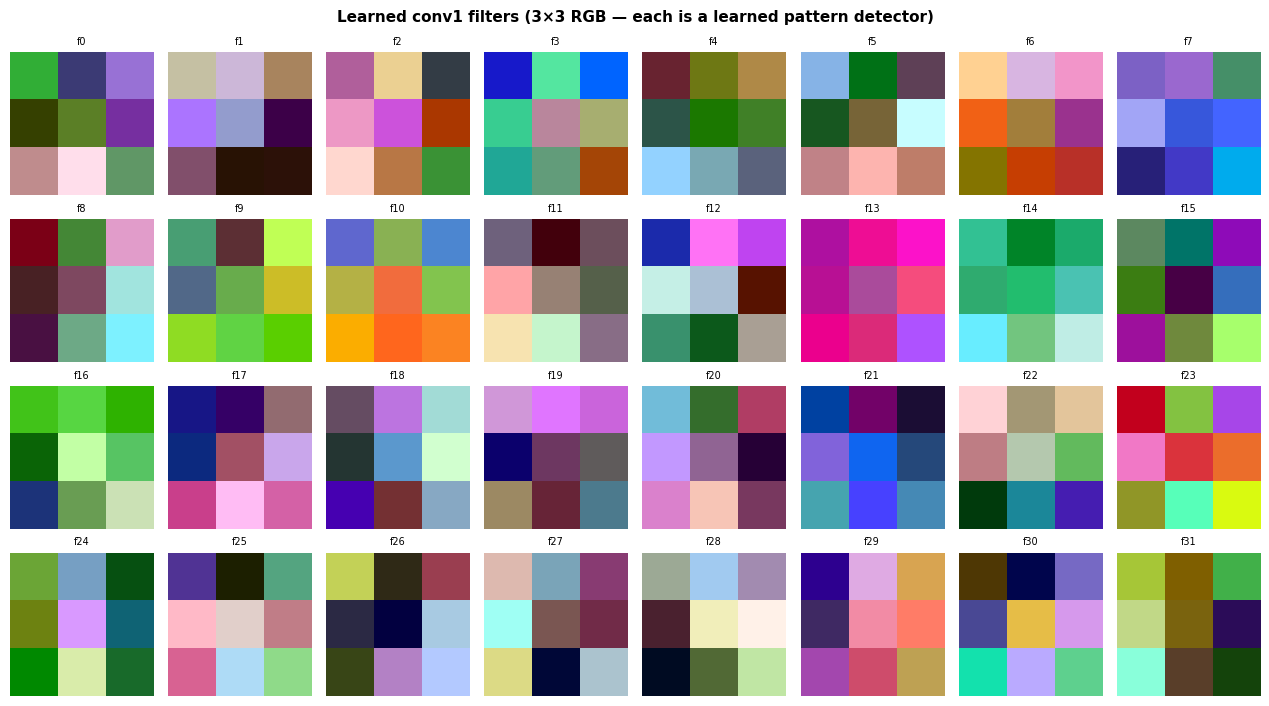

 Each 3×3 patch is the spatial footprint of one filter.
 Dark vs bright → the filter responds to contrast in that direction.
 Colourful filters → respond strongly to that colour combination.


In [ ]:
# ── Extract conv1 filter weights ─────────────────────────────────────
# get_weights() returns [kernel, bias]
# kernel shape: (kernel_h=3, kernel_w=3, in_channels=3, n_filters=32)

conv1_weights, conv1_biases = model.get_layer("conv1").get_weights()
print(f"conv1 kernel shape : {conv1_weights.shape}")
print(f"conv1 biases shape : {conv1_biases.shape}")

n_filters = conv1_weights.shape[-1]   # 32
cols = 8
rows = int(np.ceil(n_filters / cols))

fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.6, rows * 1.8))
fig.suptitle("Learned conv1 filters (3×3 RGB — each is a learned pattern detector)",
             fontsize=11, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i < n_filters:
        filt = conv1_weights[:, :, :, i]           # shape (3, 3, 3)
        # Normalise to [0, 1] for display (min-max scaling per filter)
        filt_norm = (filt - filt.min()) / (filt.max() - filt.min() + 1e-8)
        ax.imshow(filt_norm, interpolation="nearest")
        ax.set_title(f"f{i}", fontsize=7)
    ax.axis("off")

plt.tight_layout()
plt.show()

print(" Each 3×3 patch is the spatial footprint of one filter.")
print(" Dark vs bright → the filter responds to contrast in that direction.")
print(" Colourful filters → respond strongly to that colour combination.")

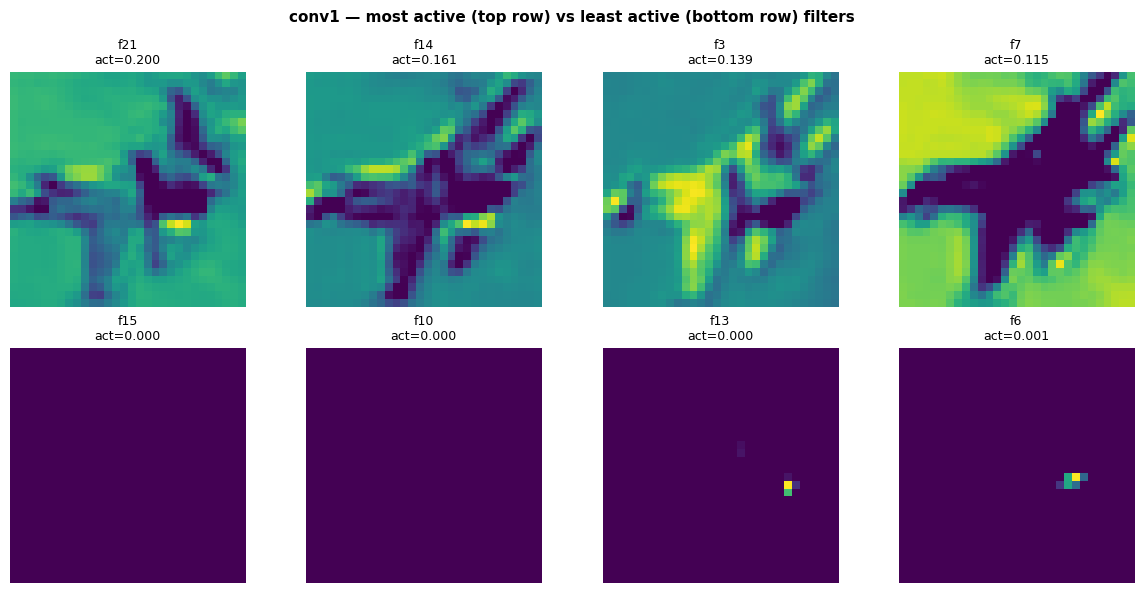

In [ ]:
# ── Zoom in on the most and least active filters ──────────────────────
# Compute the mean absolute activation of each filter across the sample image
conv1_act = activations[0]   # shape (1, 30, 30, 32)

mean_activations = conv1_act[0].mean(axis=(0, 1))   # shape (32,)
top4    = np.argsort(mean_activations)[-4:][::-1]
bottom4 = np.argsort(mean_activations)[:4]

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle("conv1 — most active (top row) vs least active (bottom row) filters",
             fontsize=11, fontweight='bold')

for i, idx in enumerate(top4):
    axes[0, i].imshow(conv1_act[0, :, :, idx], cmap="viridis")
    axes[0, i].set_title(f"f{idx}\nact={mean_activations[idx]:.3f}", fontsize=9)
    axes[0, i].axis("off")

for i, idx in enumerate(bottom4):
    axes[1, i].imshow(conv1_act[0, :, :, idx], cmap="viridis")
    axes[1, i].set_title(f"f{idx}\nact={mean_activations[idx]:.3f}", fontsize=9)
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

---
## Predictions & Evaluation

Now let's see how well the model classifies unseen test images.

In [ ]:
# ── Run predictions on the full test set ─────────────────────────────
# model.predict returns a (10000, 10) array of class probabilities

y_pred_probs = model.predict(x_test, verbose=0)        # shape (10000, 10)
y_pred       = np.argmax(y_pred_probs, axis=1)          # shape (10000,)  predicted class
y_true       = y_test.flatten()                         # shape (10000,)  true class

overall_acc = (y_pred == y_true).mean()
print(f"Overall test accuracy: {overall_acc:.2%}")

# Per-class accuracy
print("\nPer-class accuracy:")
print(f"{'Class':<12} {'Accuracy':>10}")
print("─" * 24)
for i, name in enumerate(CLASS_NAMES):
    mask = y_true == i
    acc  = (y_pred[mask] == y_true[mask]).mean()
    bar  = "█" * int(acc * 20)
    print(f"{name:<12} {acc:>6.1%}  {bar}")

Overall test accuracy: 69.52%

Per-class accuracy:
Class          Accuracy
────────────────────────
airplane      67.3%  █████████████
automobile    82.8%  ████████████████
bird          49.7%  █████████
cat           56.3%  ███████████
deer          65.0%  █████████████
dog           64.0%  ████████████
frog          71.5%  ██████████████
horse         76.4%  ███████████████
ship          83.8%  ████████████████
truck         78.4%  ███████████████


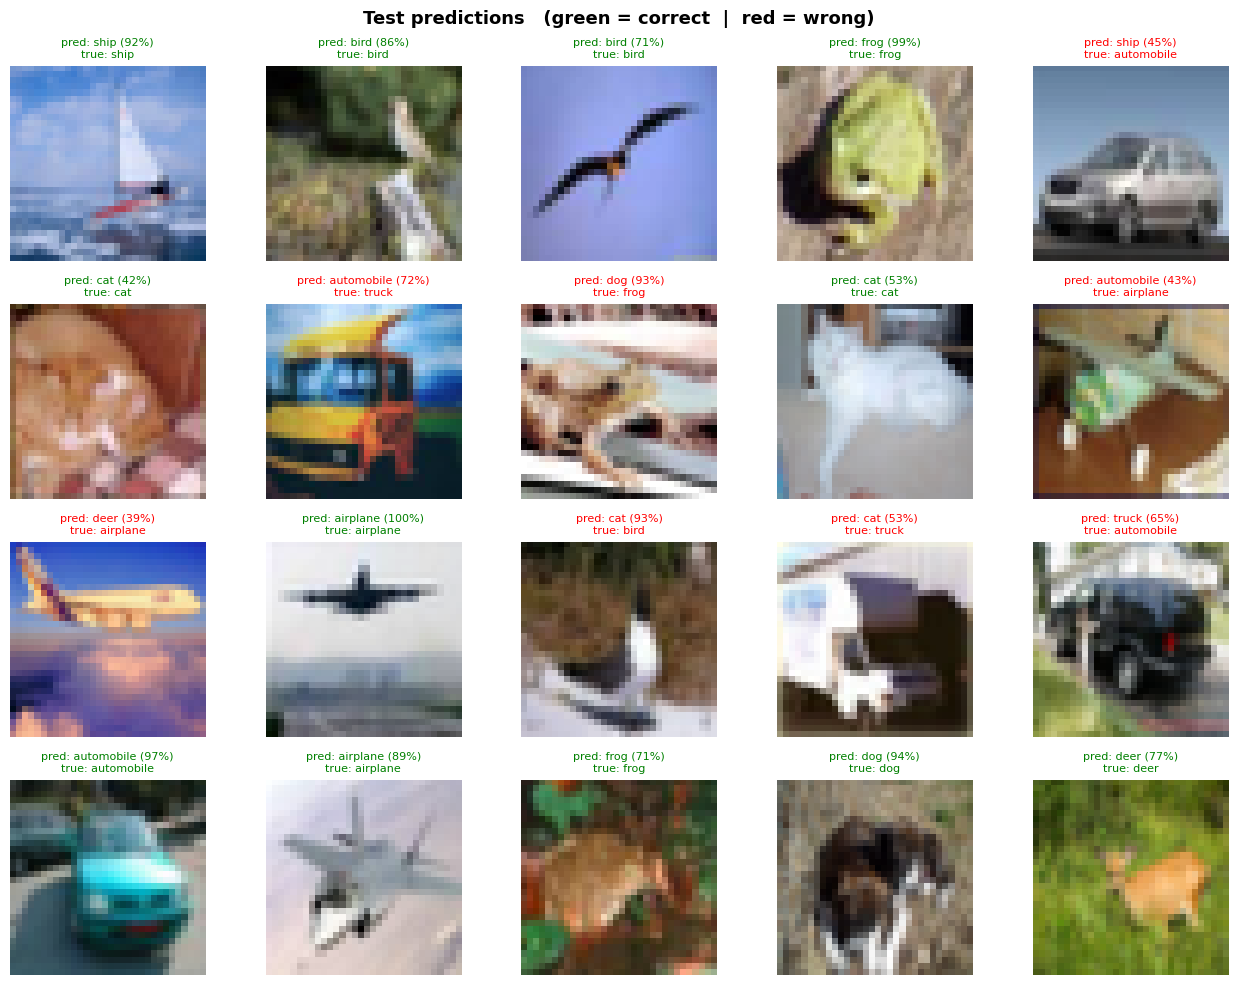

In [ ]:
# ── Visualise 20 predictions ─────────────────────────────────────────
indices = np.random.choice(len(x_test), 20, replace=False)




fig, axes = plt.subplots(4, 5, figsize=(13, 10))
fig.suptitle("Test predictions   (green = correct  |  red = wrong)",
             fontsize=13, fontweight='bold')

for ax, idx in zip(axes.flat, indices):
    ax.imshow(to_displayable(x_test[idx]))   # ← fixed line
    pred  = CLASS_NAMES[y_pred[idx]]
    true  = CLASS_NAMES[y_true[idx]]
    conf  = y_pred_probs[idx].max()
    color = "green" if pred == true else "red"
    ax.set_title(f"pred: {pred} ({conf:.0%})\ntrue: {true}",
                 fontsize=8, color=color)
    ax.axis("off")

plt.tight_layout()
plt.show()

---
## Confusion Matrix

A **confusion matrix** shows, for every true class, which class the model predicted.

- **Diagonal** = correct predictions
- **Off-diagonal** = mistakes

Common confusions in CIFAR-10:  
`cat ↔ dog`, `deer ↔ horse`, `automobile ↔ truck`  
— visually similar classes the model struggles to separate.

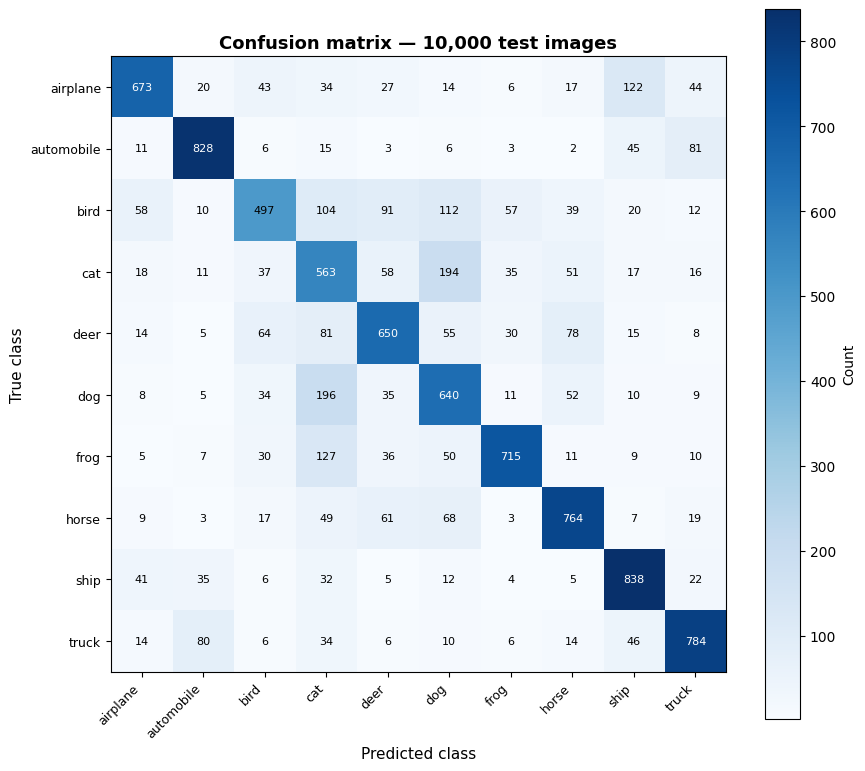

Top 5 most confused pairs (true → predicted):
  dog          → cat           (196 mistakes)
  cat          → dog           (194 mistakes)
  frog         → cat           (127 mistakes)
  airplane     → ship          (122 mistakes)
  bird         → dog           (112 mistakes)


In [ ]:
# ── Build confusion matrix (no sklearn) ───────────────────────────────
conf_matrix = np.zeros((10, 10), dtype=int)
for t, p in zip(y_true, y_pred):
    conf_matrix[t][p] += 1

# ── Plot heatmap ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(conf_matrix, cmap="Blues")

ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(CLASS_NAMES, fontsize=9)
ax.set_xlabel("Predicted class", fontsize=11)
ax.set_ylabel("True class", fontsize=11)
ax.set_title("Confusion matrix — 10,000 test images", fontsize=13, fontweight='bold')

# Annotate each cell with the count
for i in range(10):
    for j in range(10):
        val = conf_matrix[i, j]
        text_color = "white" if val > conf_matrix.max() * 0.6 else "black"
        ax.text(j, i, str(val), ha="center", va="center",
                fontsize=8, color=text_color)

plt.colorbar(im, ax=ax, label="Count")
plt.tight_layout()
plt.show()

# ── Find worst-confused pairs ─────────────────────────────────────────
print("Top 5 most confused pairs (true → predicted):")
off_diag = [(conf_matrix[i,j], CLASS_NAMES[i], CLASS_NAMES[j])
            for i in range(10) for j in range(10) if i != j]
off_diag.sort(reverse=True)
for count, true_c, pred_c in off_diag[:5]:
    print(f"  {true_c:<12} → {pred_c:<12}  ({count} mistakes)")

---
## Lab Experiments

Try these modifications and observe the effect on accuracy:

| Experiment | What to change | Expected effect |
|---|---|---|
| More filters | `Conv2D(64...)` → `Conv2D(128...)` | +1–3% accuracy, slower training |
| Remove Dropout | Delete the `Dropout` layer | Higher train acc, lower val acc (overfitting) |
| Add 3rd Conv block | Add another Conv+Pool after pool2 | Marginal gain (image too small by then) |
| BatchNorm | Add `BatchNormalization()` after each Conv | Faster, more stable training |
| Data augmentation | Use `ImageDataGenerator` | +3–5% accuracy |

The cell below shows how to add **Batch Normalisation** as a quick experiment:

In [ ]:
# ── Experiment: CNN with Batch Normalisation ─────────────────────────
# BatchNorm normalises activations within each mini-batch.
# Benefits: faster convergence, acts as a mild regulariser.

inputs_bn = layers.Input(shape=(32, 32, 3), name="input")

x = layers.Conv2D(32, (3, 3), padding="valid", name="conv1")(inputs_bn)
x = layers.BatchNormalization()(x)          # ← normalise before activation
x = layers.Activation("relu")(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(64, (3, 3), padding="valid", name="conv2")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Flatten()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.4)(x)
outputs_bn = layers.Dense(10, activation="softmax")(x)

model_bn = models.Model(inputs_bn, outputs_bn, name="cnn_with_batchnorm")
model_bn.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model_bn.summary()

print("\nRun model_bn.fit(...) to train and compare with the original model.")
print("Typically BatchNorm converges faster and reaches slightly higher accuracy.")

Model: "cnn_with_batchnorm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 612,426 (2.34 MB)

 Trainable params: 612,234 (2.34 MB)

 Non-trainable params: 192 (768.00 B)


Run model_bn.fit(...) to train and compare with the original model.
Typically BatchNorm converges faster and reaches slightly higher accuracy.


---
## Lab Summary

| Section | Key concept |
|---|---|
| 1 | CIFAR-10 dataset: 32×32 RGB images, 10 classes |
| 2 | Normalise pixels to [0,1]; one-hot encode labels |
| 3 | CNN = stacked Conv+Pool blocks → Flatten → Dense |
| 4 | Adam optimiser + cross-entropy loss; ~70–75% test acc |
| 5 | Training curves reveal overfitting when train-val gap grows |
| 6 | Feature maps show edges → textures → shapes across layers |
| 7 | Conv1 filters visualise learned edge/colour detectors |
| 8 | Per-class accuracy: ships & automobiles easiest; cats hardest |
| 9 | Confusion matrix: cat↔dog and deer↔horse most confused pairs |
| 10 | BatchNorm, extra filters, and augmentation all improve accuracy |

---